<a href="https://colab.research.google.com/github/rfaoktvian/CreditRiskPrediction/blob/main/notebooks/01_model_development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CREDIT RISK PREDICTION MODEL

### Problem Statement
When a borrower submits a loan application, a bank must make a binary decision — approve or reject — before any repayment behaviour is observed. The core challenge is that the true creditworthiness of a borrower is unobservable at the time of the decision. A bank that is too conservative loses revenue by rejecting creditworthy borrowers. A bank that is too lenient absorbs losses when borrowers default.

This project builds a machine learning model that estimates the probability of default (PD) for a loan applicant at the point of origination — using only information the borrower provides on their application, with no reliance on post-decision variables assigned by the lender.

The target variable is binary:
- 0 (Fully Paid): the borrower repaid the principal and interest in full
- 1 (Charged Off): the borrower defaulted and the debt was written off as an unrecoverable loss

### IMPORT LIBRARY

In [361]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### LOAD DATASET

In [362]:
path = '/content/drive/My Drive/Kuliah/PortfolioProject/CreditRiskPrediction/loan_data_2007_2014.csv'
df = pd.read_csv(path)

### DATA UNDERSTANDING

In [363]:
pd.set_option('display.max_columns', None)

df.head(3)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.0,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.0,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [365]:
df.describe()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,466256.000000,466256.000000,215934.000000,62638.000000,466256.000000,466256.000000,4.662850e+05,465945.000000,466256.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466140.000000,98974.000000,466285.0,0.0,0.0,0.0,466256.000000,3.960090e+05,3.960090e+05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,0.284678,0.804745,34.104430,74.306012,11.187069,0.160564,1.623020e+04,56.176947,25.064430,4410.062342,4408.452258,11540.686220,11469.892747,8866.014657,2588.677225,0.650129,85.344211,8.961534,3123.913796,0.009085,42.852547,1.0,NaN,NaN,NaN,0.004002,1.919135e+02,1.388017e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,0.797365,1.091598,21.778487,30.357653,4.987526,0.510863,2.067625e+04,23.732628,11.600141,6355.078769,6353.198001,8265.627112,8254.157579,7031.687997,2483.809661,5.265730,552.216084,85.491437,5554.737393,0.108648,21.662591,0.0,NaN,NaN,NaN,0.068637,1.463021e+04,1.521147e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,0.000000,0.000000,16.000000,53.000000,8.000000,0.000000,6.413000e+03,39.200000,17.000000,0.000000,0.000000,5552.125349,5499.250000,3708.560000,957.280000,0.000000,0.000000,0.000000,312.620000,0.000000,26.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,2.861800e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,0.000000,0.000000,31.000000,76.000000,10.000000,0.000000,1.176400e+04,57.600000,23.000000,441.470000,441.380000,9419.250943,9355.430000,6817.760000,1818.880000,0.000000,0.000000,0.000000,545.960000,0.000000,42.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,8.153900e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,0.000000,1.000000,49.000000,102.000000,14.000000,0.000000,2.033300e+04,74.700000,32.000000,7341.650000,7338.390000,15308.158460,15231.310000,12000.000000,3304.530000,0.000000,0.000000,0.000000,3187.510000,0.000000,59.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,2.089530e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [366]:
df.columns

Index(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url',
       'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'verificatio

### EXPLORATORY DATA ANALYSIS

In [367]:
pd.set_option('display.max_rows', None)

percentage_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percentage_missing})
missing_value_df = missing_value_df.sort_values(by='percent_missing', ascending=False)
print(missing_value_df)

                                             column_name  percent_missing
max_bal_bc                                    max_bal_bc       100.000000
open_rv_24m                                  open_rv_24m       100.000000
inq_fi                                            inq_fi       100.000000
open_rv_12m                                  open_rv_12m       100.000000
il_util                                          il_util       100.000000
mths_since_rcnt_il                    mths_since_rcnt_il       100.000000
total_bal_il                                total_bal_il       100.000000
open_il_24m                                  open_il_24m       100.000000
open_il_12m                                  open_il_12m       100.000000
open_il_6m                                    open_il_6m       100.000000
open_acc_6m                                  open_acc_6m       100.000000
dti_joint                                      dti_joint       100.000000
annual_inc_joint                      

Terdapat beberapa fitur yang memiliki missing values yang besar, sehingga perlu dihapus / drop

In [368]:
df['loan_status'].value_counts()

,count
loan_status,
Current,224226
Fully Paid,184739
Charged Off,42475
Late (31-120 days),6900
In Grace Period,3146
Does not meet the credit policy. Status:Fully Paid,1988
Late (16-30 days),1218
Default,832
Does not meet the credit policy. Status:Charged Off,761


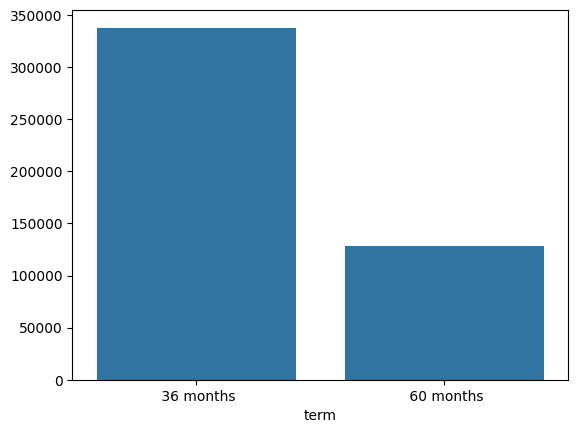

In [369]:
count = df['term'].value_counts()
sns.barplot(x = count.index,y = count.values)
plt.show()

Jangka waktu pembayaran yang dipilih peminjam paling banyak ada di 36 bulan, kemudian fitur term ini masih berupa object, dimana perlu menghapus kata 'months' agar bisa di analisis.

In [370]:
pd.crosstab(index = df['term'] ,columns = df['loan_status'],normalize = 'index')*100

loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
term,,,,,,,,,
36 months,8.123911,44.238400,0.144991,0.192039,0.529364,44.710655,0.585584,0.227546,1.247511
60 months,11.704018,58.224761,0.266496,0.087274,0.155067,26.211701,0.909360,0.349874,2.091450


Walaupun distribusi jangka waktu 36 bulan lebih banyak dipilih oleh peminjam, namun tingkat / persentase gagal bayar lebih besar di term / jangka waktu 60 bulan, menandakan lebih panjangnya jangka waktu yang dipilih memengaruhi risiko gagal bayar

In [371]:
df['grade'].value_counts()

,count
grade,
B,136929
C,125293
D,76888
A,74867
E,35757
F,13229
G,3322


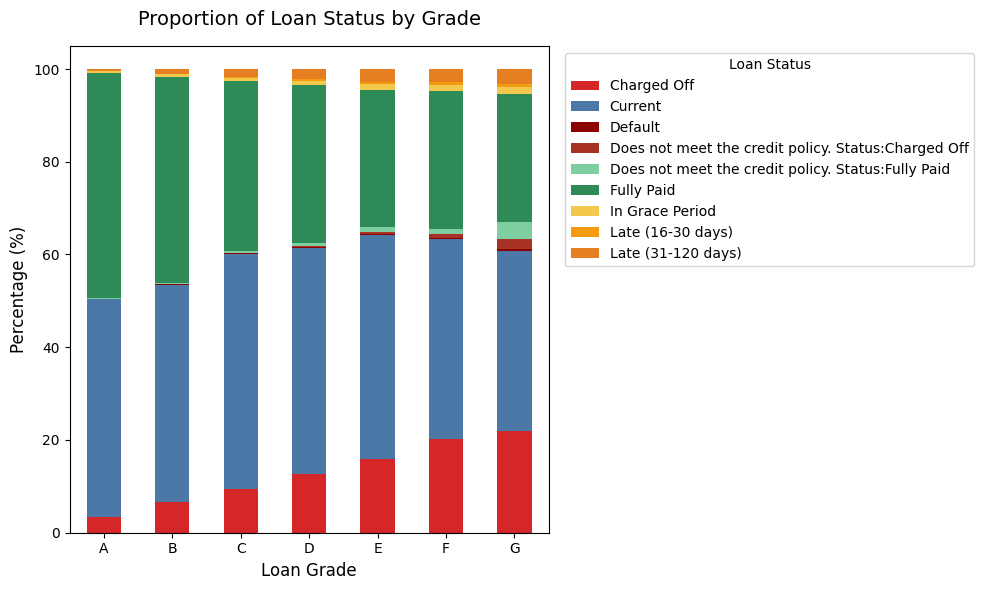

In [372]:
grade_status_pct = pd.crosstab(
    df['grade'],
    df['loan_status'],
    normalize='index'
) * 100

colors = [
    '#D62728',
    '#4C78A8',
    '#8B0000',
    '#A93226',
    '#7DCEA0',
    '#2E8B57',
    '#F2C94C',
    '#F39C12',
    '#E67E22'
]

grade_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=colors[:len(grade_status_pct.columns)]
)

plt.title('Proportion of Loan Status by Grade', fontsize=14, pad=15)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Penentuan 'grade' atau kelas ini berkorelasi bagus dalam penentuan seberapa besar potensi performa pembayaran peminjam. Data dengan kelas F-G lebih banyak memiliki persentase gagal bayar yang besar dibanding kelas A-B

In [373]:
bad_status = ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off', 'Late (31-120 days)']
df['is_default'] = np.where(df['loan_status'].isin(bad_status), 1, 0)

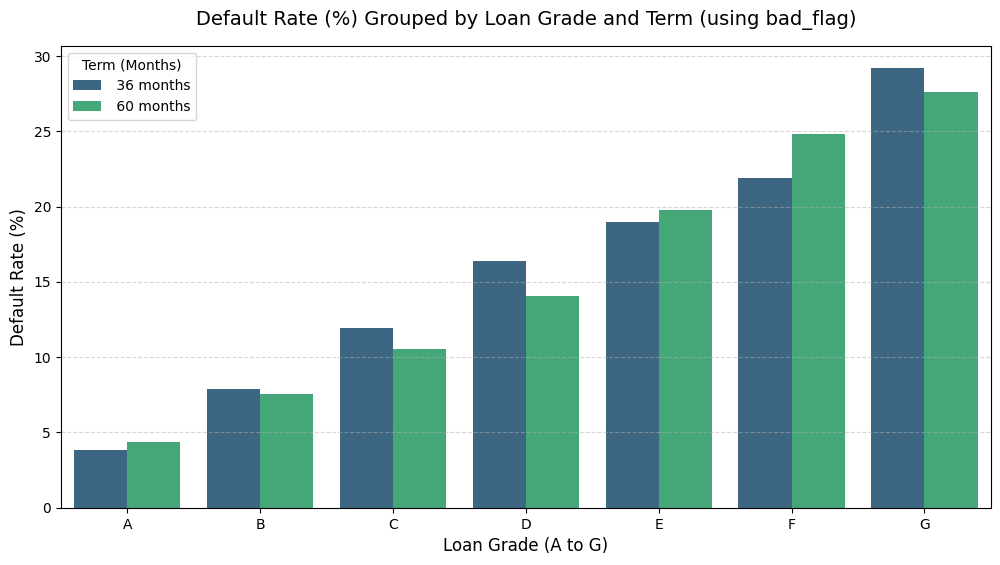

term   36 months  60 months
grade                      
A       3.855442   4.387292
B       7.895131   7.585464
C      11.939315  10.513266
D      16.399299  14.088825
E      18.963848  19.747486
F      21.882050  24.817302
G      29.223744  27.600555


In [374]:
pattern_df_bad_flag = df.groupby(['term', 'grade'])['is_default'].mean().reset_index()
pattern_df_bad_flag['default_rate_%'] = pattern_df_bad_flag['is_default'] * 100

plt.figure(figsize=(12, 6))
sns.barplot(data=pattern_df_bad_flag, x='grade', y='default_rate_%', hue='term', palette='viridis')
plt.title('Default Rate (%) Grouped by Loan Grade and Term (using bad_flag)', fontsize=14, pad=15)
plt.xlabel('Loan Grade (A to G)', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.legend(title='Term (Months)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()
print(pattern_df_bad_flag.pivot(index='grade', columns='term', values='default_rate_%'))

In [375]:
bad_loan_count = df['is_default'].sum()
good_loan_count = len(df) - bad_loan_count

print(f"Number of Good Loans: {good_loan_count}")
print(f"Number of Bad Loans: {bad_loan_count}")

if bad_loan_count > 0:
    ratio = good_loan_count / bad_loan_count
    print(f"Ratio of Good Loans to Bad Loans: {ratio:.2f} : 1")
else:
    print("There are no bad loans in the dataset.")

Number of Good Loans: 415317
Number of Bad Loans: 50968
Ratio of Good Loans to Bad Loans: 8.15 : 1


In [376]:
df.drop('loan_status',axis=1,inplace=True)

In [377]:
df['emp_length'].value_counts()

,count
emp_length,
10+ years,150049
2 years,41373
3 years,36596
< 1 year,36265
5 years,30774
1 year,29622
4 years,28023
7 years,26180
6 years,26112


Fitur empt_length perlu dibersihkan dengan menghapus kata 'years' dan beberapa tanda agar bisa di analisis. Kemudian peminjam dengan masa kerja yang tinggi (+ 10 tahun) merupakan kriteria paling banyak dari peminjam.

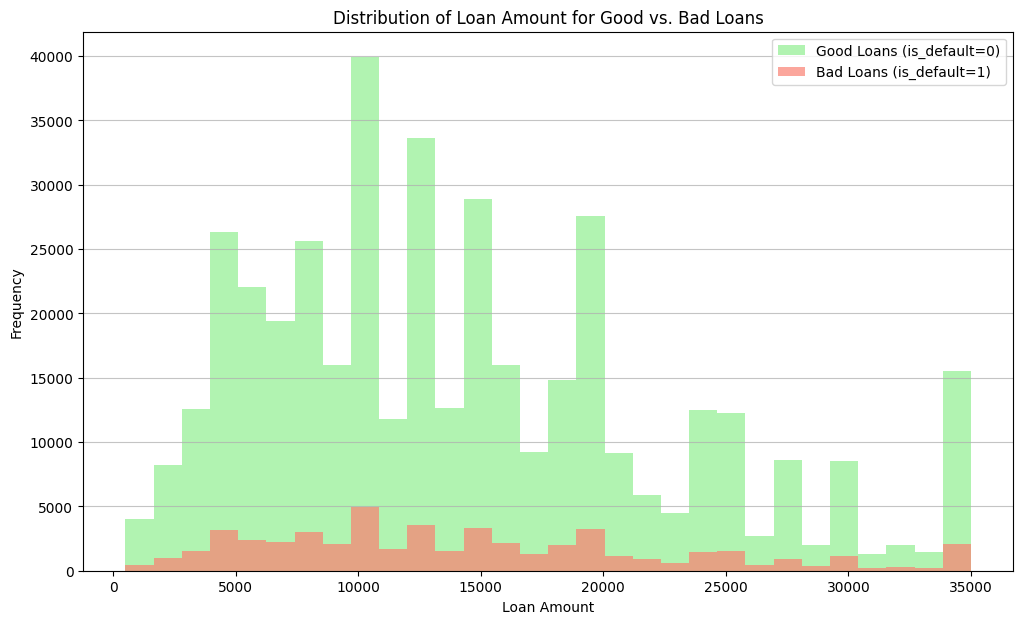

In [378]:
plt.figure(figsize=(12, 7))
plt.hist(df[df['is_default'] == 0]['loan_amnt'], bins=30, alpha=0.7, label='Good Loans (is_default=0)', color='lightgreen')
plt.hist(df[df['is_default'] == 1]['loan_amnt'], bins=30, alpha=0.7, label='Bad Loans (is_default=1)', color='salmon')
plt.title('Distribution of Loan Amount for Good vs. Bad Loans')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

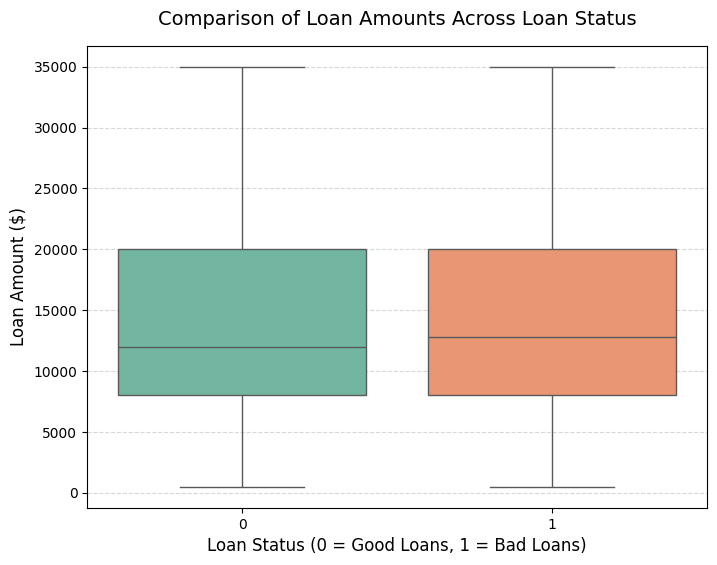

is_default
0    12000.0
1    12800.0
Name: loan_amnt, dtype: float64


In [379]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_default', y='loan_amnt', palette='Set2')
plt.title('Comparison of Loan Amounts Across Loan Status', fontsize=14, pad=15)
plt.xlabel('Loan Status (0 = Good Loans, 1 = Bad Loans)', fontsize=12)
plt.ylabel('Loan Amount ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print(df.groupby('is_default')['loan_amnt'].median())

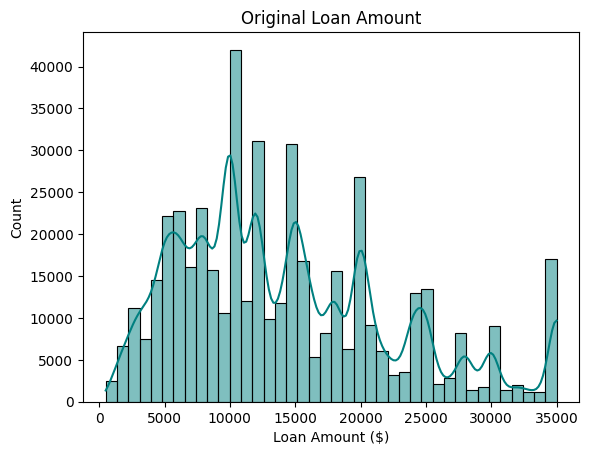

In [380]:
sns.histplot(df['loan_amnt'], bins=40, kde=True, color='teal')
plt.title('Original Loan Amount', fontsize=12)
plt.xlabel('Loan Amount ($)')
plt.ylabel('Count')
plt.show()

Minimum interset rate =  5.42
Maximum interset rate =  26.06


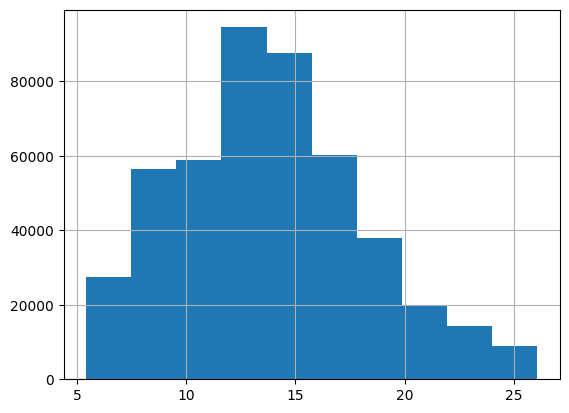

In [381]:
df['int_rate'].hist()
print('Minimum interset rate = ',df['int_rate'].min())
print('Maximum interset rate = ',df['int_rate'].max())

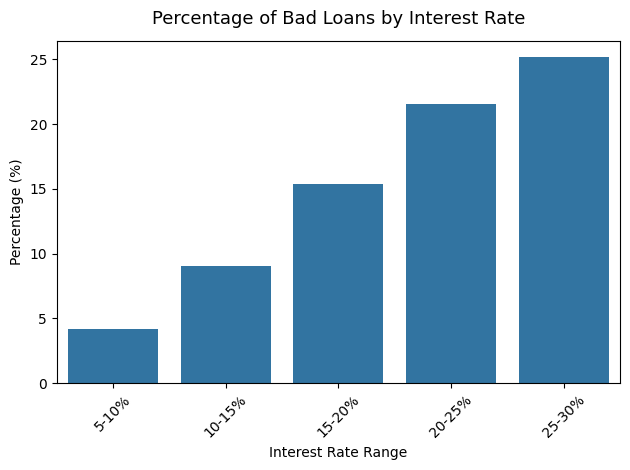

In [382]:
bins = [5, 10, 15, 20, 25, 30]
labels = ['5-10%', '10-15%', '15-20%', '20-25%', '25-30%']
df['int_rate_bins'] = pd.cut(df['int_rate'], bins=bins, labels=labels)
int_rate_pct = pd.crosstab(df['int_rate_bins'], df['is_default'], normalize='index') * 100

sns.barplot(x=int_rate_pct.index, y=int_rate_pct[1])
plt.title('Percentage of Bad Loans by Interest Rate', fontsize=13, pad=12)
plt.xlabel('Interest Rate Range')
plt.ylabel('Percentage (%)')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

df.drop(columns=['int_rate_bins'], inplace=True)

Pinjaman dengan interest rate / suku bunga yang tinggi menimbulkan potensi terjadinya gagal bayar / bad loans

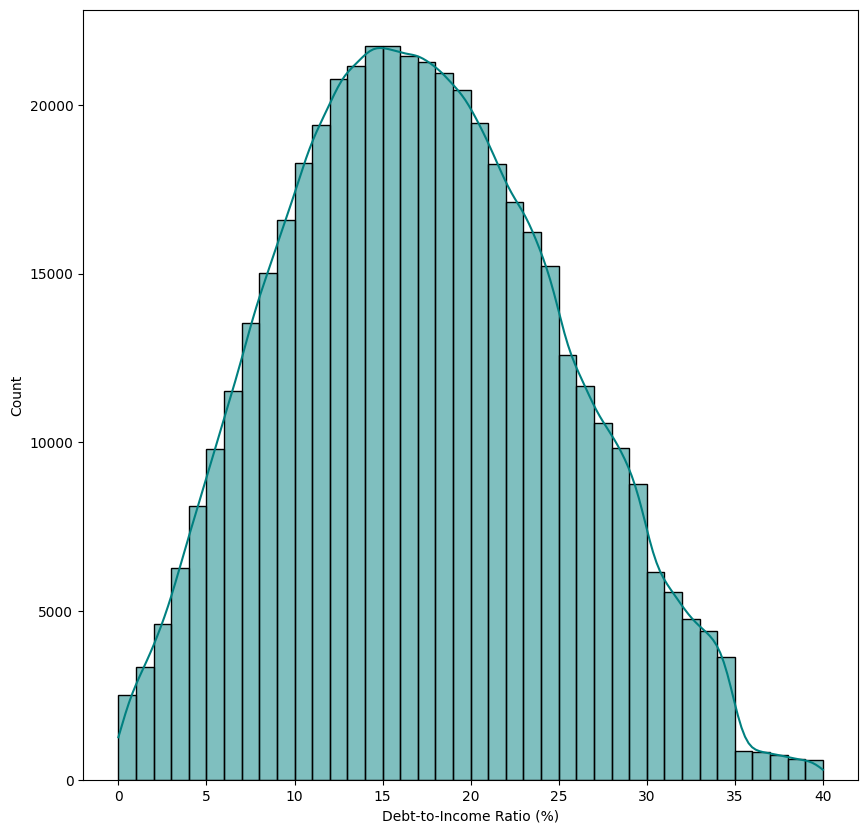

In [383]:
plt.figure(figsize=(10,10))
sns.histplot(data = df, x='dti', kde=True, color='teal', bins=40)
plt.xlabel('Debt-to-Income Ratio (%)')
plt.ylabel('Count')
plt.show()

<Axes: >

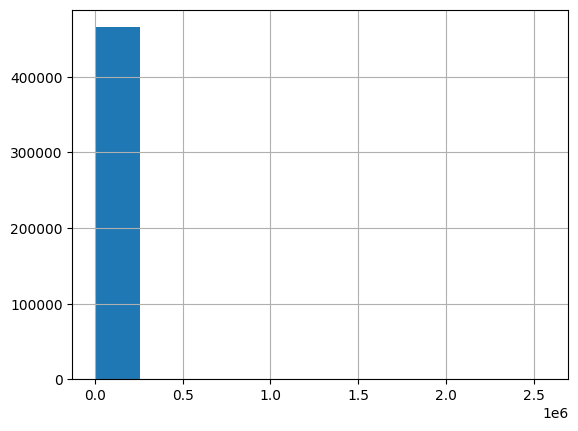

In [384]:
df['revol_bal'].hist()

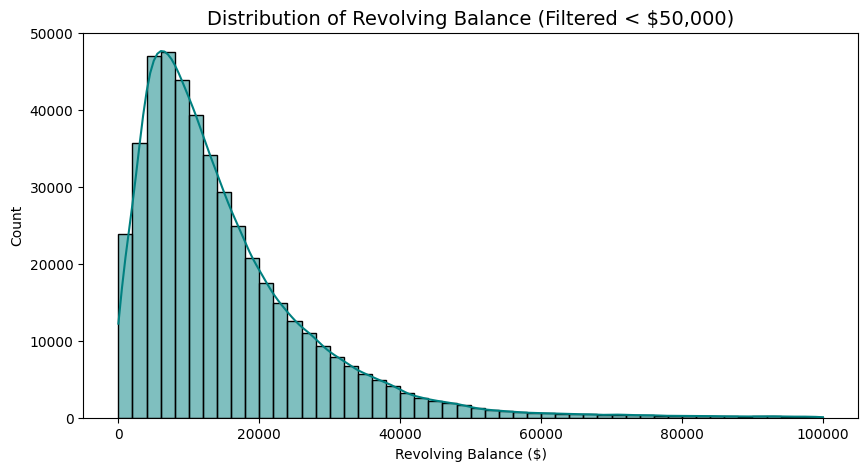

In [385]:
plt.figure(figsize=(10, 5))

sns.histplot(df[df['revol_bal'] < 100000]['revol_bal'], bins=50, kde=True, color='teal')

plt.title('Distribution of Revolving Balance (Filtered < $50,000)', fontsize=14)
plt.xlabel('Revolving Balance ($)')
plt.ylabel('Count')
plt.show()

In [386]:
pd.crosstab(columns = df['initial_list_status'],index = df['int_rate'],normalize = "index")*100

initial_list_status,f,w
int_rate,,
5.42,100.000000,0.000000
5.79,100.000000,0.000000
5.99,100.000000,0.000000
6.00,66.000000,34.000000
6.03,61.202519,38.797481
6.17,100.000000,0.000000
6.39,100.000000,0.000000
6.49,44.436165,55.563835
6.54,100.000000,0.000000


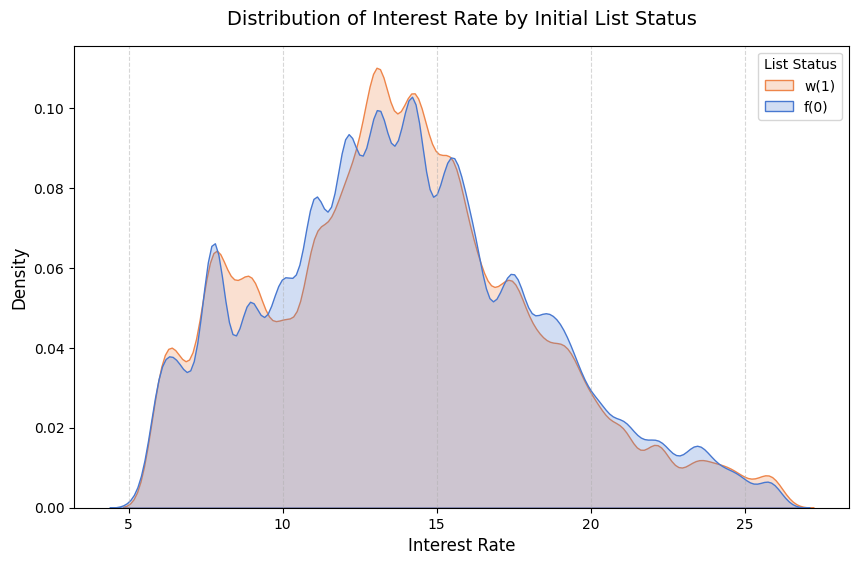

In [387]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df, x='int_rate', hue='initial_list_status', common_norm=False, fill=True, palette='muted')
plt.title('Distribution of Interest Rate by Initial List Status', fontsize=14, pad=15)
plt.xlabel('Interest Rate', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='List Status', labels=['w(1)', 'f(0)'])
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


In [388]:
# Encode sub_grade
grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
sub_grades_ordered = [f"{g}{i}" for g in grades for i in range(1, 6)]
sub_grade_map = {sub_grade: index + 1 for index, sub_grade in enumerate(sub_grades_ordered)}
df['sub_grade'] = df['sub_grade'].map(sub_grade_map).astype(int)
print("Successfully encoded sub_grade into integers:")
print(df['sub_grade'].head())

Successfully encoded sub_grade into integers:
0     7
1    14
2    15
3    11
4    10
Name: sub_grade, dtype: int64


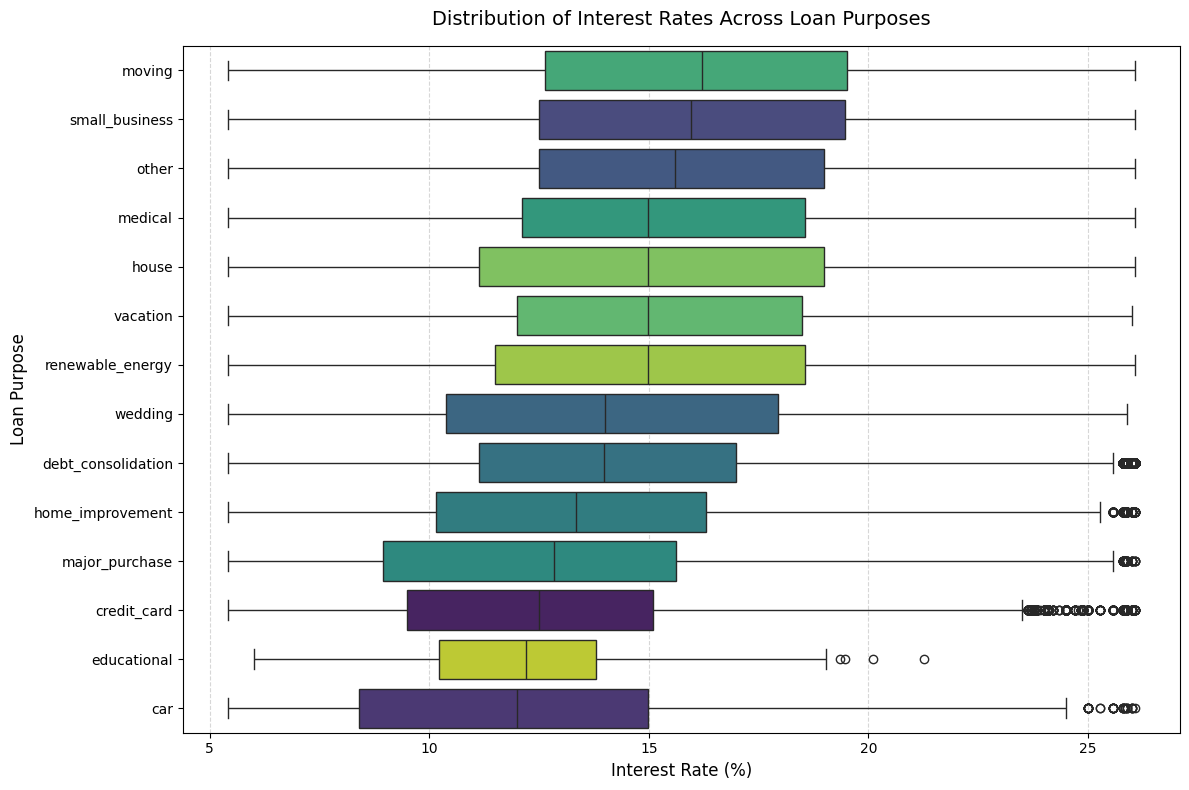

--- Summary of Average Interest Rates by Purpose ---
                         mean  median   count
purpose                                      
moving              16.032826   16.20    2994
small_business      15.983963   15.95    7013
other               15.669362   15.59   23690
medical             15.265211   14.99    4602
house               15.258184   14.99    2269
vacation            15.057612   14.99    2487
renewable_energy    15.092707   14.98     351
wedding             14.148942   13.99    2343
debt_consolidation  14.117046   13.98  274195
home_improvement    13.572315   13.35   26537
major_purchase      12.829454   12.85    9828
credit_card         12.564210   12.49  104157
educational         12.121540   12.21     422
car                 12.126489   11.99    5397


In [389]:
purpose_order = df.groupby('purpose')['int_rate'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df,
    y='purpose',
    x='int_rate',
    order=purpose_order,
    palette='viridis',
    hue='purpose',
    legend=False
)

plt.title('Distribution of Interest Rates Across Loan Purposes', fontsize=14, pad=15)
plt.xlabel('Interest Rate (%)', fontsize=12)
plt.ylabel('Loan Purpose', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("--- Summary of Average Interest Rates by Purpose ---")
print(df.groupby('purpose')['int_rate'].agg(['mean', 'median', 'count']).loc[purpose_order])

In [390]:
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,274195
credit_card,104157
home_improvement,26537
other,23690
major_purchase,9828
small_business,7013
car,5397
medical,4602
moving,2994


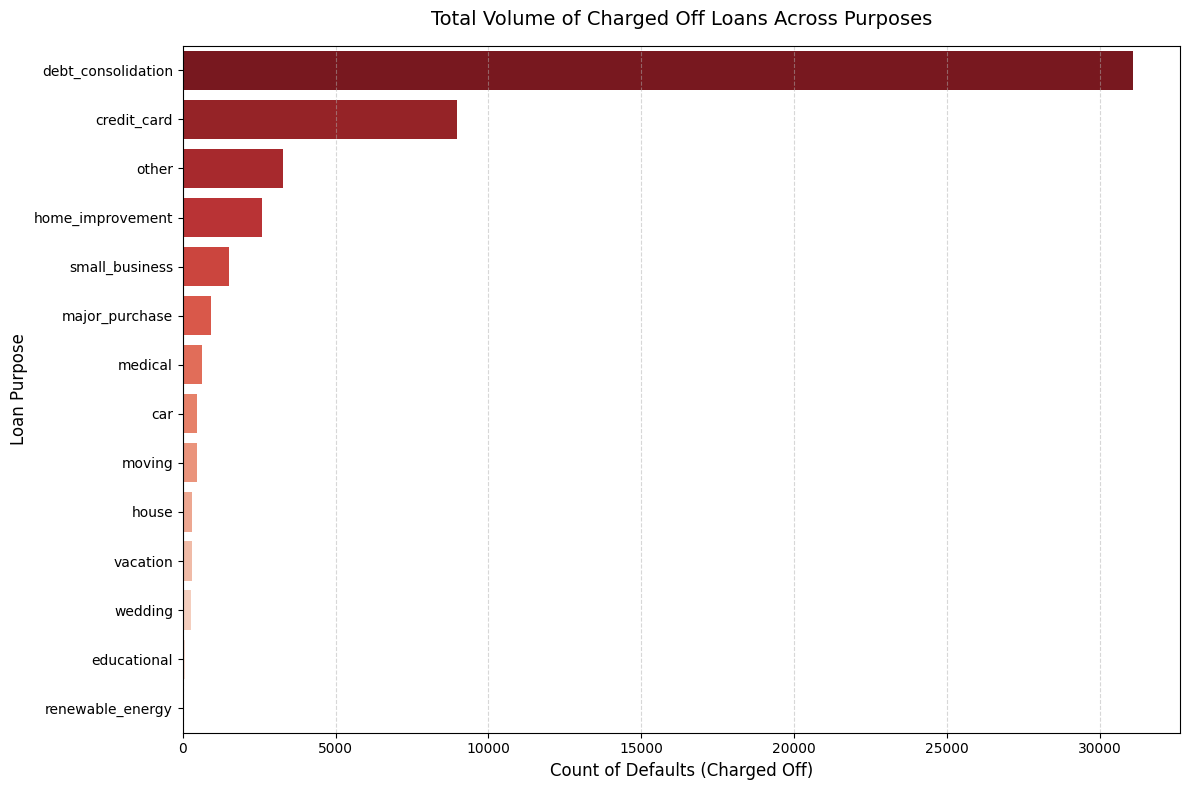

In [391]:
charged_off_counts = df[df['is_default'] == 1]['purpose'].value_counts()
df_charged_off = charged_off_counts.reset_index()
df_charged_off.columns = ['Loan Purpose', 'Number of Charged Off Loans']
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_charged_off,
    y='Loan Purpose',
    x='Number of Charged Off Loans',
    palette='Reds_r',
    hue='Loan Purpose',
    legend=False
)
plt.title('Total Volume of Charged Off Loans Across Purposes', fontsize=14, pad=15)
plt.xlabel('Count of Defaults (Charged Off)', fontsize=12)
plt.ylabel('Loan Purpose', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Tujuan 'Debt_Consolidation' memiliki kemungkinan pembayaran pinjaman gagal yang besar, sehingga pada tujuan ini, bisa lebih diperhatikan / diperketat

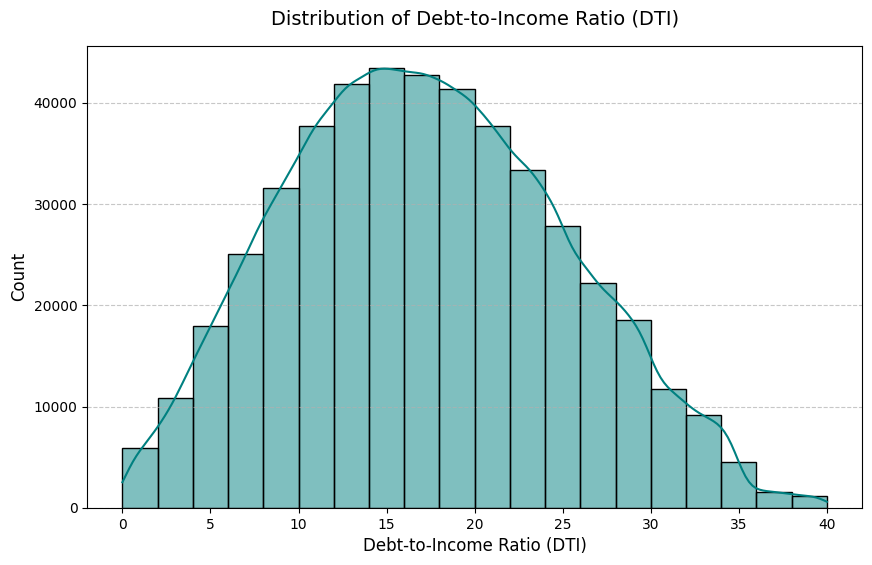

In [392]:
plt.figure(figsize=(10, 6))
sns.histplot(df['dti'], kde=True, color='teal', bins=20)
plt.title('Distribution of Debt-to-Income Ratio (DTI)', fontsize=14, pad=15)
plt.xlabel('Debt-to-Income Ratio (DTI)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### HANDLING MISSING VALUES & OUTLIERS

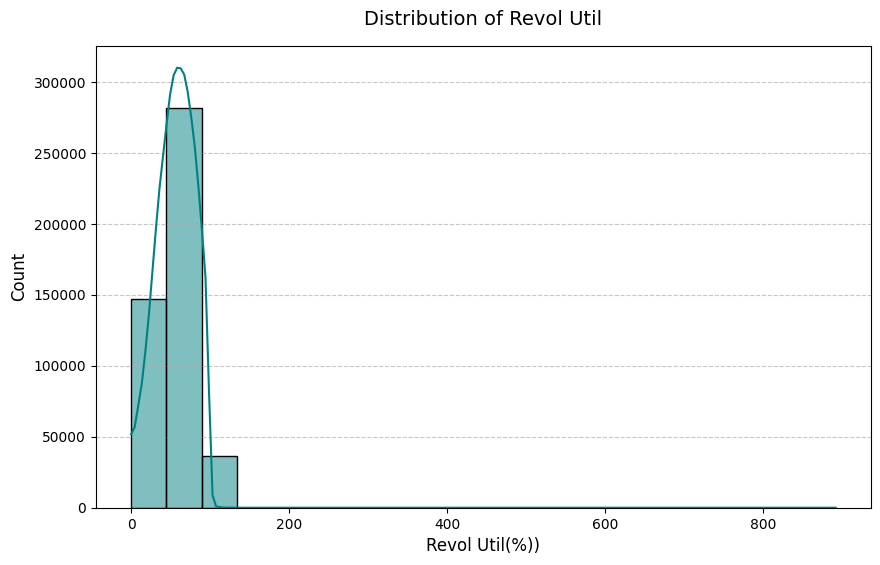

Nilai minimum Revol Util =  0.0
Nilai maksimal Revol Util = 892.3


In [393]:
plt.figure(figsize=(10, 6))
sns.histplot(df['revol_util'], kde=True, color='teal', bins=20)
plt.title('Distribution of Revol Util', fontsize=14, pad=15)
plt.xlabel('Revol Util(%))', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print('Nilai minimum Revol Util = ',df['revol_util'].min())
print('Nilai maksimal Revol Util =',df['revol_util'].max())

Distribusi dari revol util ini sangat right skewed, terdapat outlier di lebih dari 200% revol util. Outlier ini sangat ekstrem, bisa merusak performa model machine learning

In [394]:
# Handling Outlier (Revol Util)
upper_limit_revol = df['revol_util'].quantile(0.99)
df['revol_util'] = np.where(df['revol_util'] > upper_limit_revol, upper_limit_revol, df['revol_util'])

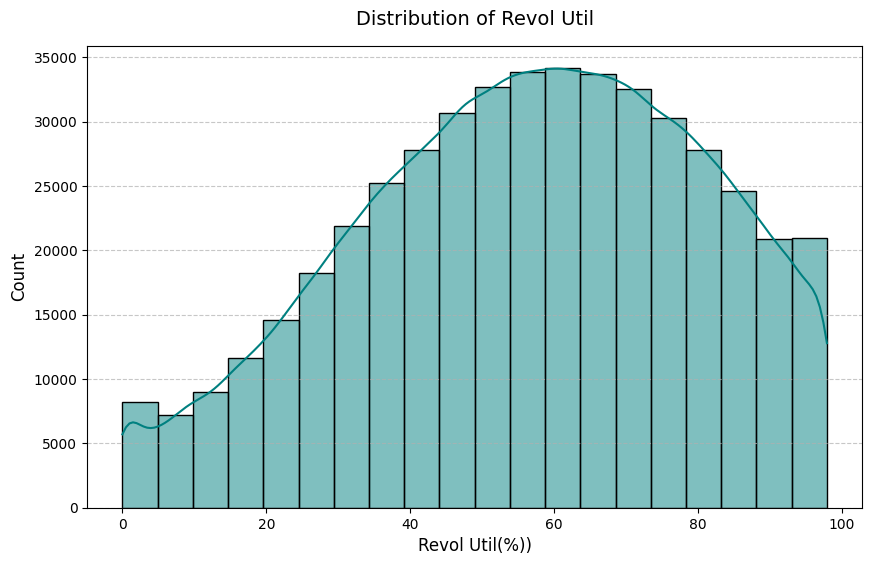

Nilai minimum Revol Util =  0.0
Nilai maksimal Revol Util = 97.9


In [395]:
plt.figure(figsize=(10, 6))
sns.histplot(df['revol_util'], kde=True, color='teal', bins=20)
plt.title('Distribution of Revol Util', fontsize=14, pad=15)
plt.xlabel('Revol Util(%))', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print('Nilai minimum Revol Util = ',df['revol_util'].min())
print('Nilai maksimal Revol Util =',df['revol_util'].max())

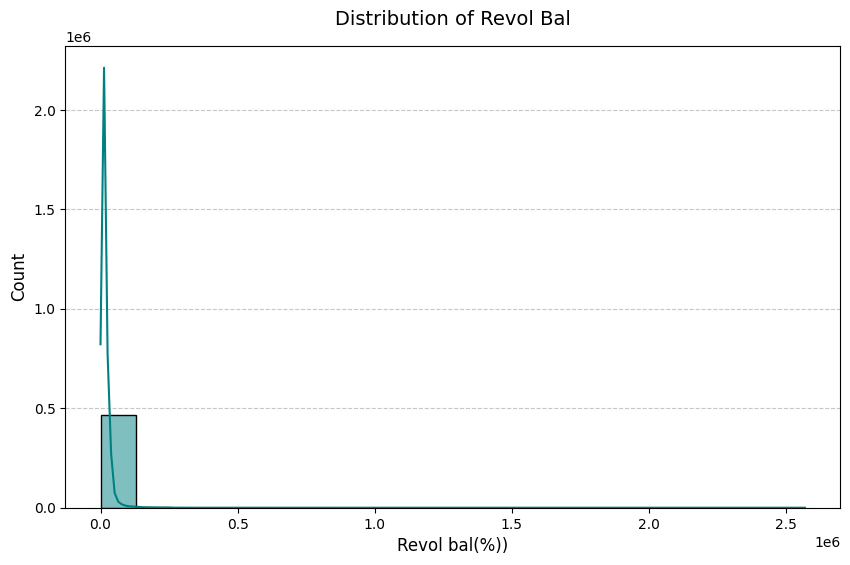

Nilai minimum Revol Util =  0
Nilai maksimal Revol Util = 2568995


In [396]:
plt.figure(figsize=(10, 6))
sns.histplot(df['revol_bal'], kde=True, color='teal', bins=20)
plt.title('Distribution of Revol Bal', fontsize=14, pad=15)
plt.xlabel('Revol bal(%))', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print('Nilai minimum Revol Util = ',df['revol_bal'].min())
print('Nilai maksimal Revol Util =',df['revol_bal'].max())

Fitur revol_bal memiliki distribusi right_skewed, di mana ada nasabah dengan saldo kecil dan segelintir nasabah dengan saldo super raksasa, sehingga hal ini perlu ditangani

In [397]:
df['log_revol_bal'] = np.log1p(df['revol_bal'])
df.drop(columns=['revol_bal'], inplace=True, errors='ignore')

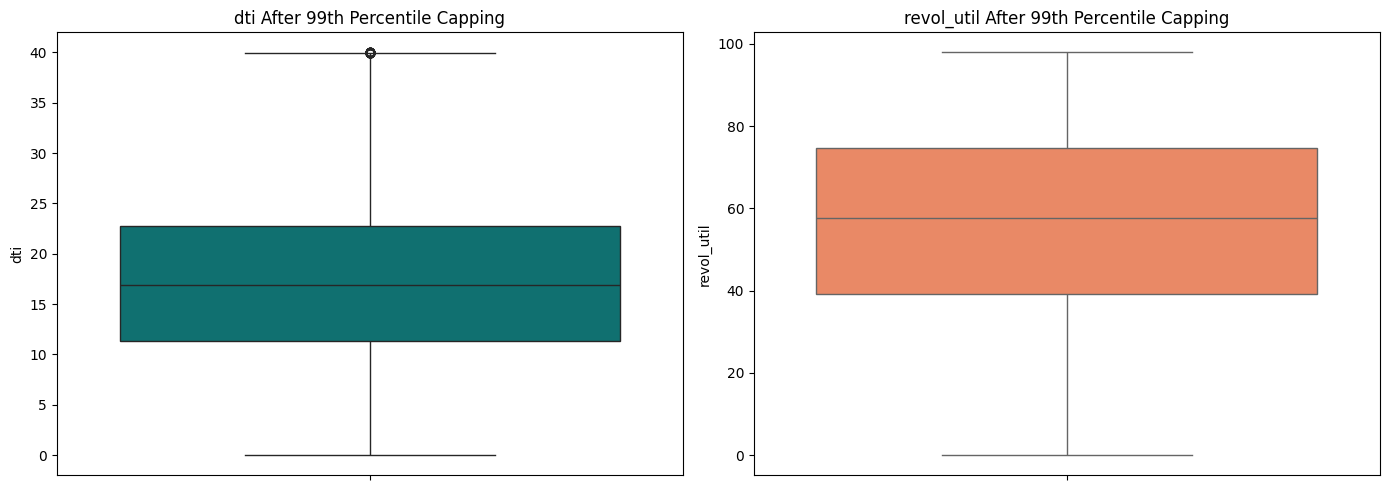

In [398]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, y='dti', ax=axes[0], color='teal')
axes[0].set_title('dti After 99th Percentile Capping')

sns.boxplot(data=df, y='revol_util', ax=axes[1], color='coral')
axes[1].set_title('revol_util After 99th Percentile Capping')

plt.tight_layout()
plt.show()

Setelah diterapkan metode 99th percentile capping, kedua fitur menunjukkan distribusi data yang bersih dan terkontrol dengan nilai DTI maksimal berada di angka 35 serta revol_util berhasil dibatasi di bawah 100% tanpa menyisakan pencilan (outliers) ekstrem.

In [399]:
df.columns

Index(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'pymnt_plan', 'url', 'desc',
       'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_util',
       'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv',
       'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'verification_status_joint', 'acc_now_delinq', 

<Axes: >

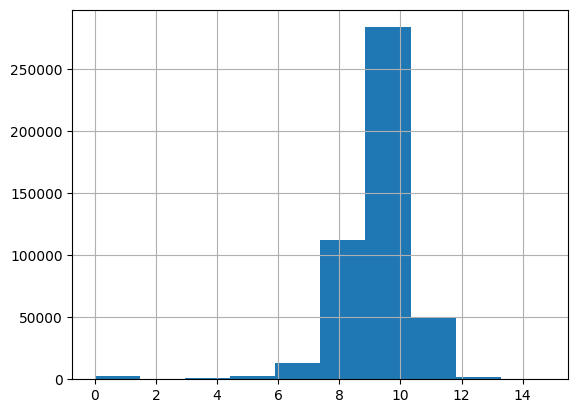

In [400]:
df['log_revol_bal'].hist()

### DATA PREPROCESSING

In [401]:
df_prep = df.copy()

In [402]:
df_prep['emp_title'].unique()

array([nan, 'Ryder', 'AIR RESOURCES BOARD', ..., 'MecÃ¡nica',
       'Chief of Interpretation (Park Ranger)', 'Server Engineer Lead'],
      dtype=object)

In [403]:
df_prep['emp_title'] = df_prep['emp_title']
df_prep['emp_title'] = df_prep['emp_title'].str.upper()

In [404]:
df_prep['emp_title'].unique()

array([nan, 'RYDER', 'AIR RESOURCES BOARD', ..., 'MECÃ¡NICA',
       'CHIEF OF INTERPRETATION (PARK RANGER)', 'SERVER ENGINEER LEAD'],
      dtype=object)

In [405]:
df_prep['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [406]:
emp_map = {"< 1 year":0,"1 year" : 1,"2 years":2,"3 years" : 3,"4 years":4,"5 years": 5,
          "6 years":6,"7 years":7,"8 years":8,"9 years":9,"10+ years":10}
df_prep['emp_length'] = df_prep['emp_length'].map(emp_map)
df_prep['emp_length'] = df_prep['emp_length'].fillna(0)
df_prep['emp_length'] = df_prep['emp_length'].astype('int64')

In [407]:
df_prep['home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER', 'NONE', 'ANY'], dtype=object)

In [408]:
df_prep['home_ownership'].value_counts(dropna=False)

,count
home_ownership,
MORTGAGE,235875
RENT,188473
OWN,41704
OTHER,182
NONE,50
ANY,1


In [409]:
df_prep['home_ownership'] = df_prep['home_ownership'].replace({
    'ANY': 'OTHER',
    'NONE': 'OTHER'
})

In [410]:
df_prep = pd.get_dummies(
    df_prep,
    columns=['home_ownership'],
    drop_first=True,
    dtype='int8'
)

In [411]:
df_prep.columns

Index(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'annual_inc',
       'verification_status', 'issue_d', 'pymnt_plan', 'url', 'desc',
       'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_util',
       'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv',
       'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt',
  

In [412]:
df_prep.drop(columns = ['verification_status','url','desc','title','pymnt_plan'],inplace = True)

In [413]:
df_prep.drop(columns = ['funded_amnt','funded_amnt_inv'],inplace= True)

fitur funded_amnt dan funded_amnt_inv memiliki kesamaan / similarity yang tinggi dengan fitur loan_amnt

In [414]:
df_prep['revol_util'].isnull().sum()

np.int64(340)

In [415]:
df_prep['revol_util'] = df_prep['revol_util'].fillna(df_prep['revol_util'].median())

In [416]:
df_prep['initial_list_status'].unique()

array(['f', 'w'], dtype=object)

<Axes: >

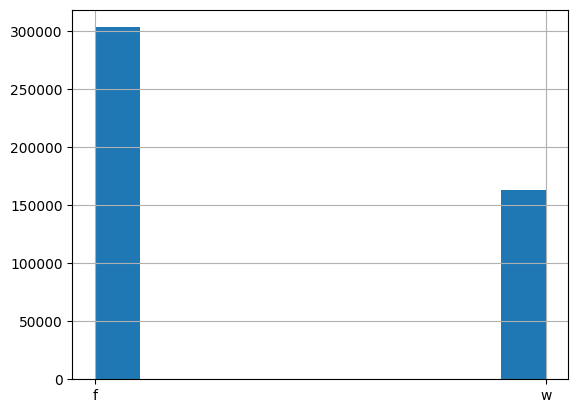

In [417]:
df_prep['initial_list_status'].hist()

In [418]:
df_prep.drop(columns = 'initial_list_status',inplace = True)


In [419]:
df_prep['mths_since_last_delinq'].describe()

,mths_since_last_delinq
count,215934.000000
mean,34.104430
std,21.778487
min,0.000000
25%,16.000000
50%,31.000000
75%,49.000000
max,188.000000


In [420]:
df_prep['mths_since_last_record'].describe()

,mths_since_last_record
count,62638.000000
mean,74.306012
std,30.357653
min,0.000000
25%,53.000000
50%,76.000000
75%,102.000000
max,129.000000


In [421]:
df_prep['mths_since_last_record'].unique()

array([ nan, 113., 105.,  97.,  33.,  93.,  52.,  85.,  90.,  91., 114.,
        92., 117.,  87.,  45.,  83., 118.,  38., 101., 100., 112., 110.,
        88.,  79.,  77., 107., 102.,  98.,  95., 103.,  96., 116., 111.,
        89., 108.,  29., 106., 115.,  53.,  86.,  57.,  63.,  94., 109.,
        99., 104.,  76.,  61.,  28.,  23.,  75.,  47.,  82.,  21.,  62.,
        44.,  80.,  67., 119.,  42.,  34.,  66.,  58.,  22.,  56.,  72.,
        64.,  50.,  69.,  49.,  74.,  35.,  12.,  26.,  78.,  54.,  37.,
        73.,  11.,  31.,  59.,  32.,  81.,  68.,  55.,  39.,  51.,  70.,
        30.,  41.,  71.,  40.,  43.,  27.,  65.,  46.,  19.,  17.,  25.,
        13.,  48.,  36.,   7.,  60.,  14.,   6.,  18.,   0.,  20., 120.,
       129.,   5.,  24.,  15.,  84.,  10.,  16.,   8.,   9.,   3., 121.,
         4.,   1.,   2.])

<Axes: >

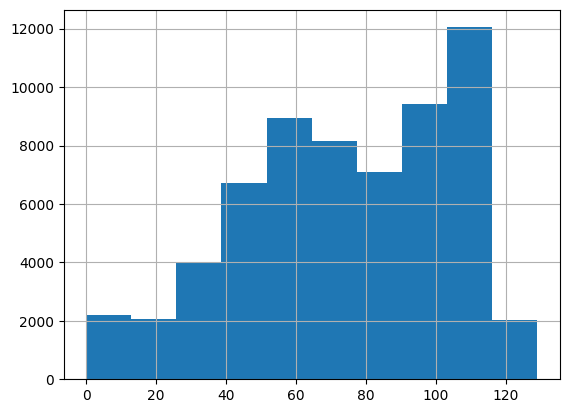

In [422]:
df_prep['mths_since_last_record'].hist()

<Axes: >

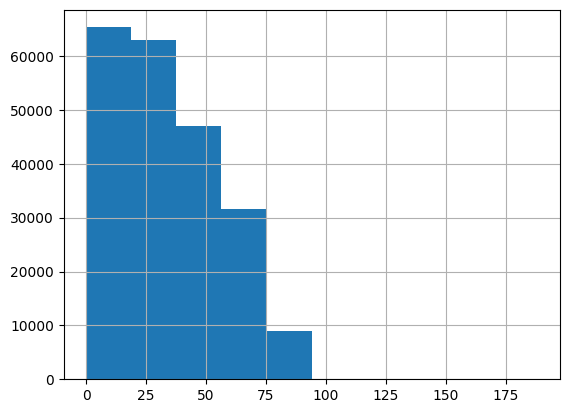

In [423]:
df_prep['mths_since_last_delinq'].hist()

In [424]:
df_prep['mths_since_last_delinq'].fillna(999, inplace=True)
df_prep['mths_since_last_record'].fillna(999, inplace=True)

In [425]:
df_prep['purpose'].unique()

array(['credit_card', 'car', 'small_business', 'other', 'wedding',
       'debt_consolidation', 'home_improvement', 'major_purchase',
       'medical', 'moving', 'vacation', 'house', 'renewable_energy',
       'educational'], dtype=object)

In [426]:
df_prep = pd.get_dummies(data = df_prep,columns =['purpose'],drop_first = True)
df_prep.head()

,Unnamed: 0,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,annual_inc,issue_d,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,is_default,log_revol_bal,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,0,1077501,1296599,5000,36 months,10.65,162.87,B,7,NaN,10,24000.0,Dec-11,860xx,AZ,27.65,0.0,Jan-85,1.0,999.0,999.0,3.0,0.0,83.7,9.0,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,9.521422,0,0,1,True,False,False,False,False,False,False,False,False,False,False,False,False
1,1,1077430,1314167,2500,60 months,15.27,59.83,C,14,RYDER,0,30000.0,Dec-11,309xx,GA,1.00,0.0,Apr-99,5.0,999.0,999.0,3.0,0.0,9.4,4.0,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,7.431300,0,0,1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2,1077175,1313524,2400,36 months,15.96,84.33,C,15,NaN,10,12252.0,Dec-11,606xx,IL,8.72,0.0,Nov-01,2.0,999.0,999.0,2.0,0.0,97.9,10.0,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,7.991931,0,0,1,False,False,False,False,False,False,False,False,False,False,True,False,False
3,3,1076863,1277178,10000,36 months,13.49,339.31,C,11,AIR RESOURCES BOARD,10,49200.0,Dec-11,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,999.0,10.0,0.0,21.0,37.0,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.630343,0,0,1,False,False,False,False,False,False,False,False,True,False,False,False,False
4,4,1075358,1311748,3000,60 months,12.69,67.79,B,10,UNIVERSITY MEDICAL GROUP,1,80000.0,Dec-11,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,999.0,15.0,0.0,53.9,38.0,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,10.232216,0,0,1,False,False,False,False,False,False,False,False,True,False,False,False,False


In [427]:
df_prep['term'] = np.int64(df_prep['term'].str.replace("months",""))

In [428]:
df_prep.head()

,Unnamed: 0,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,annual_inc,issue_d,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,is_default,log_revol_bal,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,0,1077501,1296599,5000,36,10.65,162.87,B,7,NaN,10,24000.0,Dec-11,860xx,AZ,27.65,0.0,Jan-85,1.0,999.0,999.0,3.0,0.0,83.7,9.0,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,9.521422,0,0,1,True,False,False,False,False,False,False,False,False,False,False,False,False
1,1,1077430,1314167,2500,60,15.27,59.83,C,14,RYDER,0,30000.0,Dec-11,309xx,GA,1.00,0.0,Apr-99,5.0,999.0,999.0,3.0,0.0,9.4,4.0,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,7.431300,0,0,1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2,1077175,1313524,2400,36,15.96,84.33,C,15,NaN,10,12252.0,Dec-11,606xx,IL,8.72,0.0,Nov-01,2.0,999.0,999.0,2.0,0.0,97.9,10.0,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,7.991931,0,0,1,False,False,False,False,False,False,False,False,False,False,True,False,False
3,3,1076863,1277178,10000,36,13.49,339.31,C,11,AIR RESOURCES BOARD,10,49200.0,Dec-11,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,999.0,10.0,0.0,21.0,37.0,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.630343,0,0,1,False,False,False,False,False,False,False,False,True,False,False,False,False
4,4,1075358,1311748,3000,60,12.69,67.79,B,10,UNIVERSITY MEDICAL GROUP,1,80000.0,Dec-11,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,999.0,15.0,0.0,53.9,38.0,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,10.232216,0,0,1,False,False,False,False,False,False,False,False,True,False,False,False,False


In [429]:
 df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 81 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   term                         466285 non-null  int64  
 5   int_rate                     466285 non-null  float64
 6   installment                  466285 non-null  float64
 7   grade                        466285 non-null  object 
 8   sub_grade                    466285 non-null  int64  
 9   emp_title                    438697 non-null  object 
 10  emp_length                   466285 non-null  int64  
 11  annual_inc                   466281 non-null  float64
 12  issue_d                      466285 non-null  object 
 13 

In [430]:
cols_to_drop = [
    'max_bal_bc', 'open_rv_24m', 'inq_fi', 'open_rv_12m', 'il_util',
    'mths_since_rcnt_il', 'total_bal_il', 'open_il_24m', 'open_il_12m',
    'open_il_6m', 'open_acc_6m', 'dti_joint', 'annual_inc_joint',
    'verification_status_joint', 'all_util', 'inq_last_12m', 'total_cu_tl'

    # useless feature
    ,'zip_code'
]


df_prep.drop(columns=cols_to_drop, inplace=True)

print(f"Jumlah kolom setelah di-drop: {df_prep.shape[1]}")

Jumlah kolom setelah di-drop: 63


In [431]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 63 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   term                         466285 non-null  int64  
 5   int_rate                     466285 non-null  float64
 6   installment                  466285 non-null  float64
 7   grade                        466285 non-null  object 
 8   sub_grade                    466285 non-null  int64  
 9   emp_title                    438697 non-null  object 
 10  emp_length                   466285 non-null  int64  
 11  annual_inc                   466281 non-null  float64
 12  issue_d                      466285 non-null  object 
 13 

In [432]:
df_prep['annual_inc'].describe()

,annual_inc
count,4.662810e+05
mean,7.327738e+04
std,5.496357e+04
min,1.896000e+03
25%,4.500000e+04
50%,6.300000e+04
75%,8.896000e+04
max,7.500000e+06


In [433]:
df_prep['loan_income_ratio'] = (
    df_prep['loan_amnt'] / df_prep['annual_inc']
)

In [434]:
df_prep[['loan_amnt','annual_inc','loan_income_ratio']].head()

,loan_amnt,annual_inc,loan_income_ratio
0,5000,24000.0,0.208333
1,2500,30000.0,0.083333
2,2400,12252.0,0.195886
3,10000,49200.0,0.203252
4,3000,80000.0,0.037500


In [435]:
df_prep['log_annual_inc'] = np.log1p(df_prep['annual_inc'])


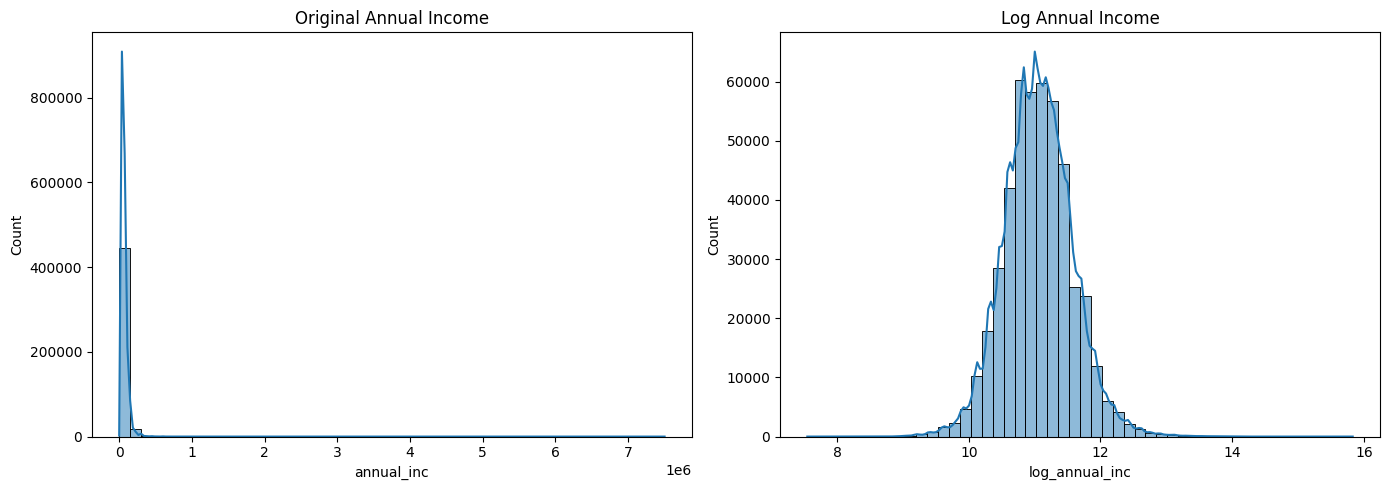

In [436]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(df_prep['annual_inc'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Original Annual Income")

sns.histplot(df_prep['log_annual_inc'], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log Annual Income")

plt.tight_layout()

In [437]:
df_prep.drop(columns='annual_inc', inplace=True)

In [438]:
df = df_prep.copy()

In [439]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 64 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   term                         466285 non-null  int64  
 5   int_rate                     466285 non-null  float64
 6   installment                  466285 non-null  float64
 7   grade                        466285 non-null  object 
 8   sub_grade                    466285 non-null  int64  
 9   emp_title                    438697 non-null  object 
 10  emp_length                   466285 non-null  int64  
 11  issue_d                      466285 non-null  object 
 12  addr_state                   466285 non-null  object 
 13 

### FEATURE ENGINEERING

In [440]:
# Convert ke datetime
df['issue_d_dt'] = pd.to_datetime(
    df['issue_d'],
    format='%b-%y'
)

df['earliest_cr_line_dt'] = pd.to_datetime(
    df['earliest_cr_line'],
    format='%b-%y'
)

In [441]:
df['issue_year'] = df['issue_d_dt'].dt.year

In [442]:
mask = df['earliest_cr_line_dt'] > df['issue_d_dt']

df.loc[mask, 'earliest_cr_line_dt'] = (
    df.loc[mask, 'earliest_cr_line_dt'] - pd.DateOffset(years=100)
)

df['credit_history_length'] = (
    (df['issue_d_dt'] - df['earliest_cr_line_dt']).dt.days / 30.44
)

df['credit_history_length'] = (
    df['credit_history_length']
    .fillna(df['credit_history_length'].median())
)

In [443]:
df['credit_history_length'].describe()

,credit_history_length
count,466285.000000
mean,191.223184
std,87.679125
min,6.044678
25%,131.997372
50%,174.014455
75%,234.954008
max,841.885677


In [444]:
df.drop(
    columns=[
        'issue_d',
        'earliest_cr_line',
        'issue_d_dt',
        'earliest_cr_line_dt'
    ],
    inplace=True)

In [445]:
df.shape

(466285, 64)

In [446]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 64 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   term                         466285 non-null  int64  
 5   int_rate                     466285 non-null  float64
 6   installment                  466285 non-null  float64
 7   grade                        466285 non-null  object 
 8   sub_grade                    466285 non-null  int64  
 9   emp_title                    438697 non-null  object 
 10  emp_length                   466285 non-null  int64  
 11  addr_state                   466285 non-null  object 
 12  dti                          466285 non-null  float64
 13 

In [447]:
df.columns

Index(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_util', 'total_acc', 'out_prncp', 'out_prncp_inv',
       'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'total_rev_hi_lim', 'is_default', 'log_revol_bal',
       'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
       'purpose_credit_card', 'purpose_debt_consolidation',
       'purpose_educational', 'purpose_home_improvement', 'purpose_ho

In [448]:
drop_cols = [
    # Identifier
    'Unnamed: 0',
    'id',
    'member_id',
    'url',

    # Text Features
    'emp_title',
    'desc',
    'title',

    # Data Leakage
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'next_pymnt_d',
    'last_credit_pull_d'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [449]:
df.shape

(466285, 47)

In [450]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 47 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    466285 non-null  int64  
 1   term                         466285 non-null  int64  
 2   int_rate                     466285 non-null  float64
 3   installment                  466285 non-null  float64
 4   grade                        466285 non-null  object 
 5   sub_grade                    466285 non-null  int64  
 6   emp_length                   466285 non-null  int64  
 7   addr_state                   466285 non-null  object 
 8   dti                          466285 non-null  float64
 9   delinq_2yrs                  466256 non-null  float64
 10  inq_last_6mths               466256 non-null  float64
 11  mths_since_last_delinq       466285 non-null  float64
 12  mths_since_last_record       466285 non-null  float64
 13 

In [451]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_util', 'total_acc', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'application_type',
       'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'is_default', 'log_revol_bal', 'home_ownership_OTHER',
       'home_ownership_OWN', 'home_ownership_RENT', 'purpose_credit_card',
       'purpose_debt_consolidation', 'purpose_educational',
       'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase',
       'purpose_medical', 'purpose_moving', 'purpose_other',
       'purpose_renewable_energy', 'purpose_small_business',
       'purpose_vacation', 'purpose_wedding', 'loan_income_ratio',
       'log_annual_inc', 'issue_year', 'credit_history_length'],
      dtype='object')

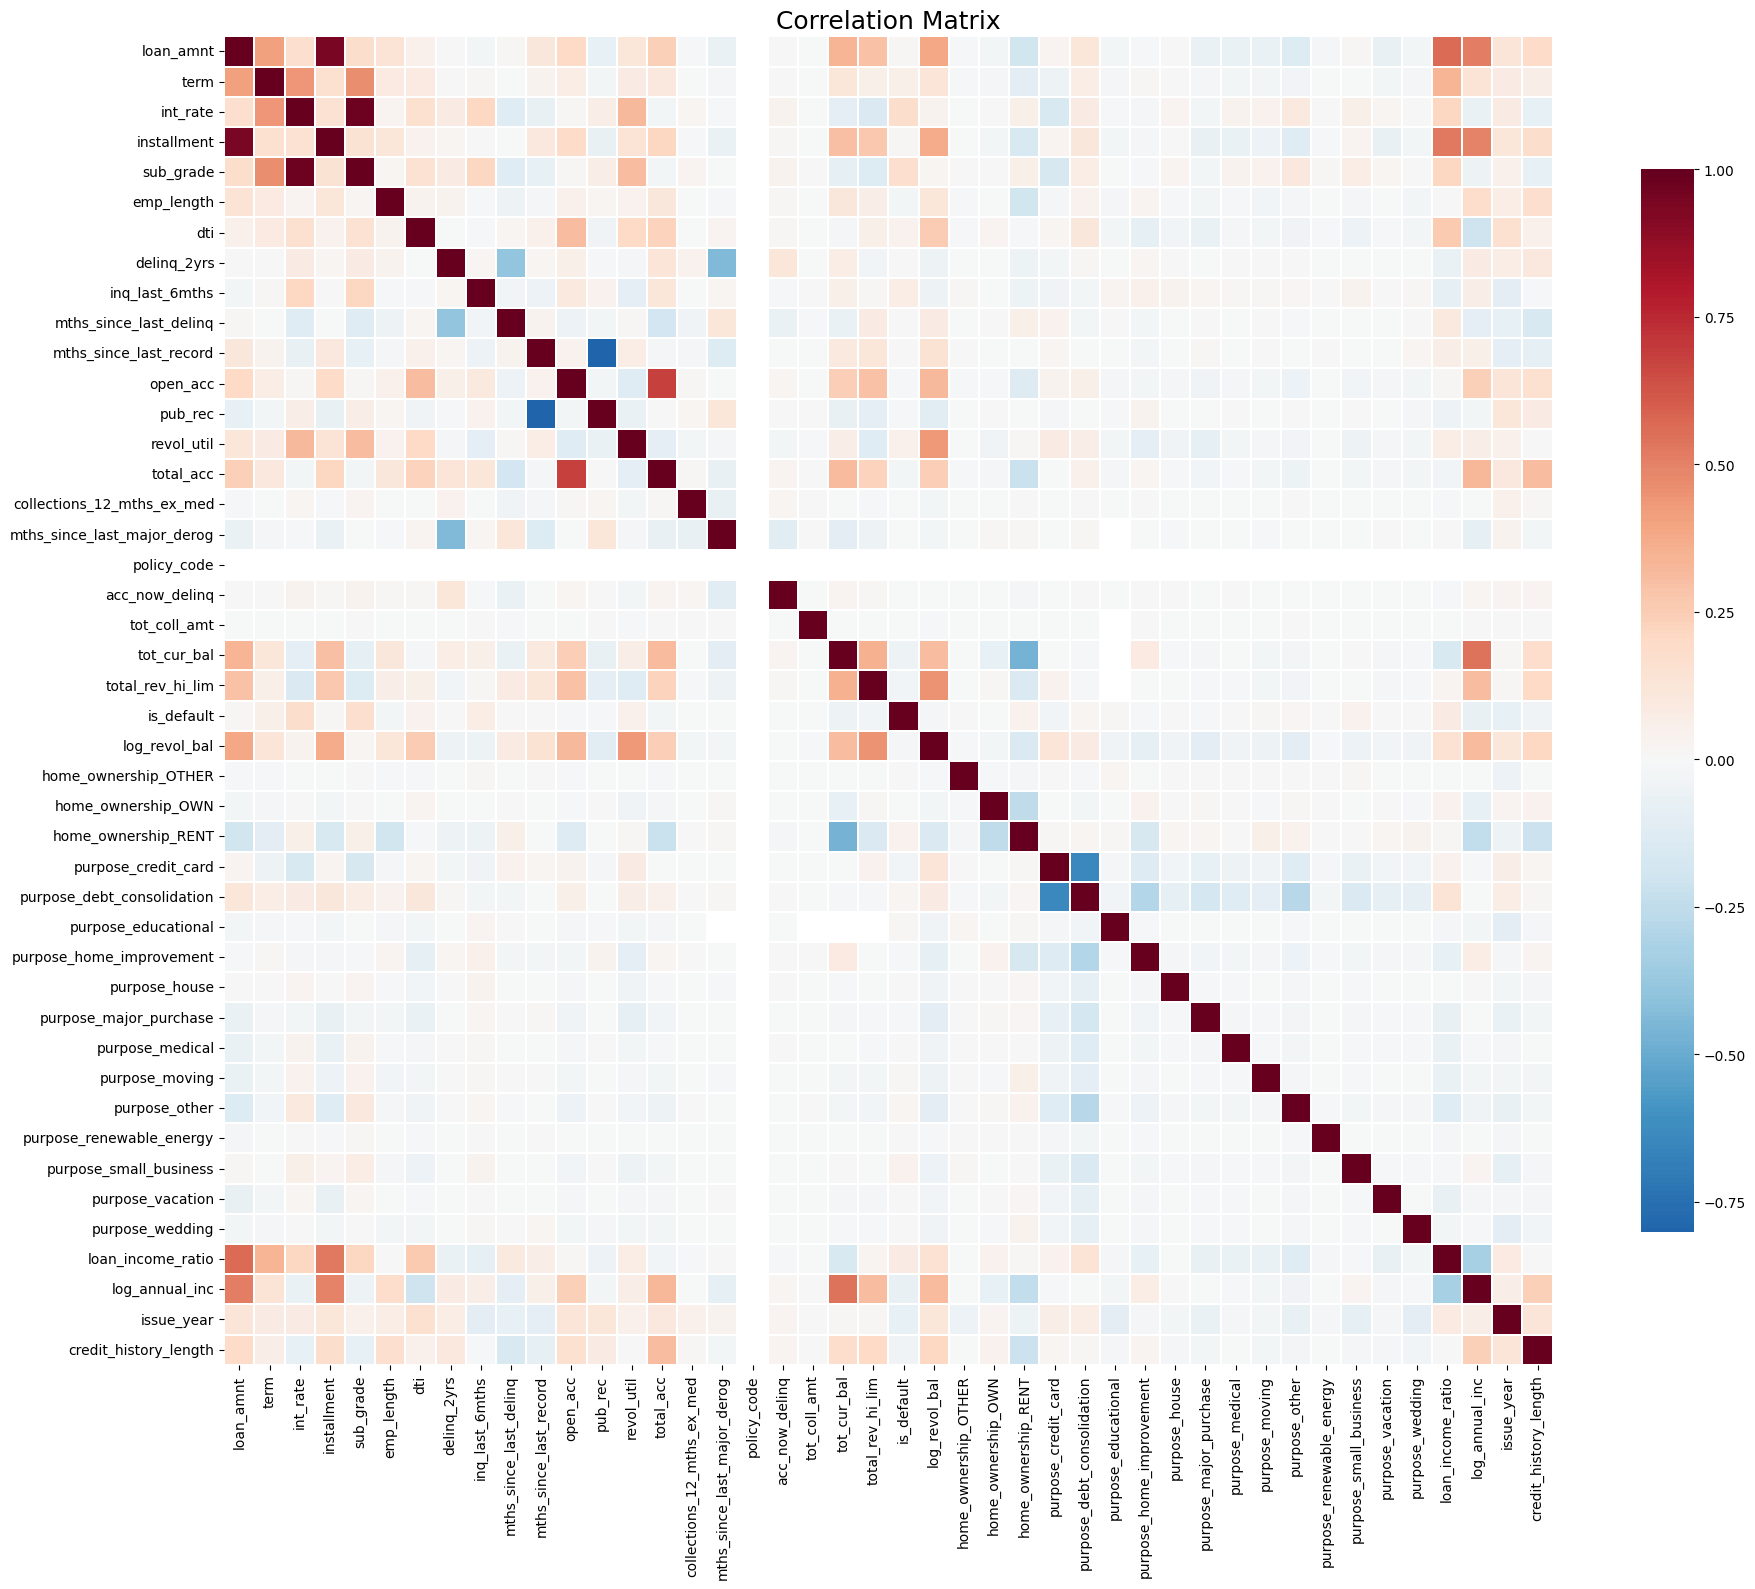

In [452]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix', fontsize=18)
plt.tight_layout()
plt.show()

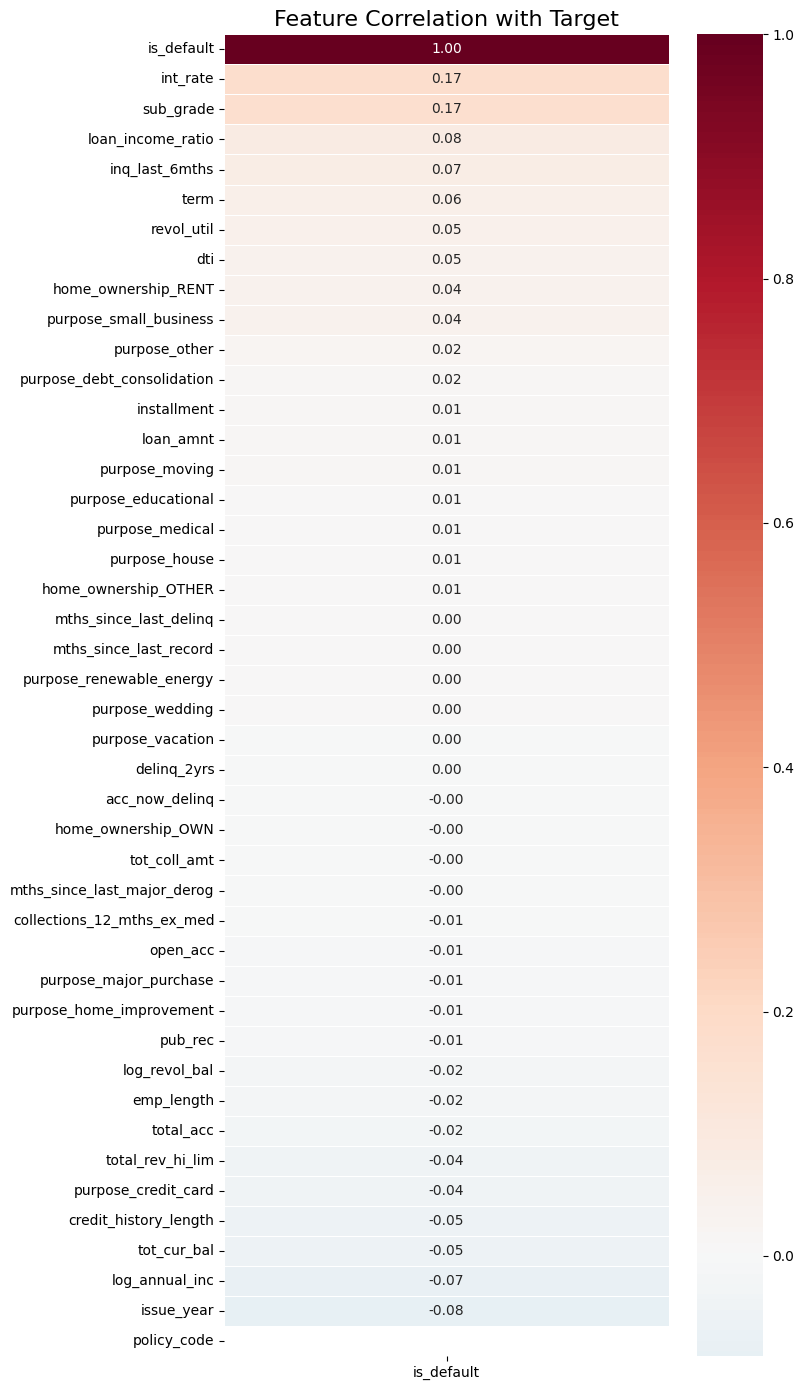

In [453]:
corr_target = (
    df.corr(numeric_only=True)['is_default']
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 14))

sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)

plt.title('Feature Correlation with Target', fontsize=16)

plt.tight_layout()
plt.show()

In [454]:
df['policy_code'].value_counts()

,count
policy_code,
1,466285


In [457]:
df['application_type'].value_counts()

,count
application_type,
INDIVIDUAL,466285


In [462]:
df.drop(['policy_code','application_type'], axis=1, inplace=True)

In [463]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 45 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    466285 non-null  int64  
 1   term                         466285 non-null  int64  
 2   int_rate                     466285 non-null  float64
 3   installment                  466285 non-null  float64
 4   grade                        466285 non-null  object 
 5   sub_grade                    466285 non-null  int64  
 6   emp_length                   466285 non-null  int64  
 7   addr_state                   466285 non-null  object 
 8   dti                          466285 non-null  float64
 9   delinq_2yrs                  466256 non-null  float64
 10  inq_last_6mths               466256 non-null  float64
 11  mths_since_last_delinq       466285 non-null  float64
 12  mths_since_last_record       466285 non-null  float64
 13 

In [466]:
df['collections_12_mths_ex_med'] = (
    df['collections_12_mths_ex_med']
    .fillna(0)
)

cols = [
    'tot_coll_amt',
    'tot_cur_bal',
    'total_rev_hi_lim'
]

for col in cols:
    df[col] = df_prep[col].fillna(df[col].median())

df.drop(
    columns=['mths_since_last_major_derog'],
    inplace=True
)

In [467]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 44 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   466285 non-null  int64  
 1   term                        466285 non-null  int64  
 2   int_rate                    466285 non-null  float64
 3   installment                 466285 non-null  float64
 4   grade                       466285 non-null  object 
 5   sub_grade                   466285 non-null  int64  
 6   emp_length                  466285 non-null  int64  
 7   addr_state                  466285 non-null  object 
 8   dti                         466285 non-null  float64
 9   delinq_2yrs                 466256 non-null  float64
 10  inq_last_6mths              466256 non-null  float64
 11  mths_since_last_delinq      466285 non-null  float64
 12  mths_since_last_record      466285 non-null  float64
 13  open_acc      

In [475]:
missing_pct = (df.isnull().mean() * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(missing_pct)

delinq_2yrs          0.006219
inq_last_6mths       0.006219
open_acc             0.006219
pub_rec              0.006219
total_acc            0.006219
acc_now_delinq       0.006219
loan_income_ratio    0.000858
log_annual_inc       0.000858
dtype: float64


In [476]:
zero_fill_cols = [
    'delinq_2yrs',
    'inq_last_6mths',
    'pub_rec',
    'acc_now_delinq'
]

median_fill_cols = [
    'open_acc',
    'total_acc',
    'loan_income_ratio',
    'log_annual_inc'
]

df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

for col in median_fill_cols:
    df[col] = df[col].fillna(df[col].median())

In [478]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 44 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   466285 non-null  int64  
 1   term                        466285 non-null  int64  
 2   int_rate                    466285 non-null  float64
 3   installment                 466285 non-null  float64
 4   grade                       466285 non-null  object 
 5   sub_grade                   466285 non-null  int64  
 6   emp_length                  466285 non-null  int64  
 7   addr_state                  466285 non-null  object 
 8   dti                         466285 non-null  float64
 9   delinq_2yrs                 466285 non-null  float64
 10  inq_last_6mths              466285 non-null  float64
 11  mths_since_last_delinq      466285 non-null  float64
 12  mths_since_last_record      466285 non-null  float64
 13  open_acc      

### SPLIT TRAIN & TEST DATA

In [479]:
X = df_prep.drop(columns='is_default')
y = df_prep['is_default']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### ENCODING

In [482]:
X_train.drop(columns='grade', inplace=True)
X_test.drop(columns='grade', inplace=True)

In [483]:
df['addr_state'].unique()

array(['AZ', 'GA', 'IL', 'CA', 'OR', 'NC', 'TX', 'VA', 'MO', 'CT', 'UT',
       'FL', 'NY', 'PA', 'MN', 'NJ', 'KY', 'OH', 'SC', 'RI', 'LA', 'MA',
       'WA', 'WI', 'AL', 'CO', 'KS', 'NV', 'AK', 'MD', 'WV', 'VT', 'MI',
       'DC', 'SD', 'NH', 'AR', 'NM', 'MT', 'HI', 'WY', 'OK', 'DE', 'MS',
       'TN', 'IA', 'NE', 'ID', 'IN', 'ME'], dtype=object)

In [484]:
X_train = pd.get_dummies(
    X_train,
    columns=['addr_state'],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=['addr_state'],
    drop_first=True
)

X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

### SCALING

In [485]:
numeric_cols = X_train.select_dtypes(
    include=['int64','float64']
).columns

In [486]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)